<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit con brazos de tipo binomial


*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy, softmax y ucb1 en un problema de k-armed bandit con brazos de tipo binomial.
Se generan gráficas de recompensas promedio, selección del brazo óptimo, regret acumulado y estadísticas por brazo (una cada vez) para cada algoritmo.

## Preparación del entorno


In [1]:
#@title Importamos todas las clases y funciones

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, Softmax, UCB1
from arms import ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


## Experimento


Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio, selección del brazo óptimo, regret acumulado y estadísticas de los brazos.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan tres algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recompensas obtenidas en esas 500 veces.

In [2]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret_accumulated = np.zeros((len(algorithms), steps)) # Matriz de arrepentimiento acumulado

    arm_stats = [
        {
            "reward_sum": np.zeros(len(bandit.arms)), # Suma de premios en cada brazo
            "selections": np.zeros(len(bandit.arms)), # Número de veces que se selecciona cada brazo
            "optimal_arm": bandit.optimal_arm # Número del brazo óptimo
        }
        for _ in algorithms # Lo crea tantas veces por algoritmos tengamos
    ]

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        q_star = current_bandit.get_expected_value(current_bandit.optimal_arm) # q_star es el valor esperado del mejor brazo

        regret_per_run = np.zeros((len(algorithms), steps)) # Matriz de arrepentimiento por run

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                if chosen_arm == optimal_arm: # Si el brazo elegido es el óptimo
                    optimal_selections[idx, step] += 1 # Aumenta en 1 el número de selecciones óptimas en cada paso

                regret = q_star - reward # El arrepentimiento es el valor esperado del mejor brazo - la recompensa del brazo actual

                if step == 0:
                    regret_per_run[idx, step] = regret # En el primer paso cogemos el arrepentimiento actual
                else:
                    regret_per_run[idx, step] = (regret_per_run[idx, step - 1] + regret) # En los siguientes pasos el arrepentimiento el arrepentimiento acumulado más el arrepentimiento del paso actual

                arm_stats[idx]["selections"][chosen_arm] += 1 # Se aumenta el número de selecciones a 1 del brazo elegido por algoritmo
                arm_stats[idx]["reward_sum"][chosen_arm] += reward # Se suma todos los premios del brazo elegido por algoritmo

        regret_accumulated += regret_per_run # Regret acumulado por run

    rewards /= runs # Promedio de las recompensas

    optimal_selections = (optimal_selections / runs) * 100 # Saca el porcentaje de selección óptima de cada algoritmo en cada paso

    regret_accumulated /= runs # Promedio del arrepentimiento

    return rewards, optimal_selections, regret_accumulated, arm_stats


## Ejecución del experimento


Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan:
- Tres algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.
- Tres algoritmos softmax para valores tau: 0.2, 0.5 y 1.0.
- Tres algoritmos UCB1 para valores coeficiente: 0.0, 1.41 y 4.0.

In [3]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithmsEpsilon = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Definir los algoritmos a comparar. En este caso son 3 algoritmos Softmax con diferentes valores de tau.
algorithmsSoftmax = [Softmax(k=k, tau=0.2), Softmax(k=k, tau=0.5), Softmax(k=k, tau=1.0)]

# Definir los algoritmos a comparar. En este caso son 3 algoritmos UCB1 con diferentes valores de c.
algorithmsUCB1 = [UCB1(k=k, c=0.0), UCB1(k=k, c=1.41), UCB1(k=k, c=4.0)]

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsEpsilon, optimal_selections_Epsilon, regret_accumulated_Epsilon, arm_stats_Epsilon = run_experiment(bandit, algorithmsEpsilon, steps, runs)

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsSoftmax, optimal_selections_Softmax, regret_accumulated_Softmax, arm_stats_Softmax = run_experiment(bandit, algorithmsSoftmax, steps, runs)

# Ejecutar el experimento y obtener las recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas de los brazos para cada algoritmo.
rewardsUCB1, optimal_selections_UCB1, regret_accumulated_UCB1, arm_stats_UCB1 = run_experiment(bandit, algorithmsUCB1, steps, runs)


Bandit with 10 arms: ArmBinomial(n=100, p=0.4), ArmBinomial(n=100, p=0.86), ArmBinomial(n=100, p=0.69), ArmBinomial(n=100, p=0.58), ArmBinomial(n=100, p=0.22), ArmBinomial(n=100, p=0.22), ArmBinomial(n=100, p=0.15), ArmBinomial(n=100, p=0.79), ArmBinomial(n=100, p=0.58), ArmBinomial(n=100, p=0.67)
Optimal arm: 2 with expected reward=86.0


## Visualización de los resultados

Aquí visualizaremos cuatro tipo de gráficas:
- Recompensa promedio con respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Selección de brazo óptimo respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Regrets acumulados respecto a los pasos de tiempo: tres gráficas en total, una por algoritmo, de las cuales en cada gráfica se podrá visualizar 3 líneas según sus parámetros.
- Estadísticas de cada brazo: 9 gráficas en total, tres por algoritmo, una por parámetro epsilon, tau o coeficiente.

### Análisis previo sobre los 3 primeros tipos de gráficas

En cuanto a las imágenes de los 3 primeros tipos de gráfica tendremos en cuenta lo siguiente:

1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Tres líneas de colores distintos representan diferentes valores de $\tau$ en el algoritmo Softmax:**
   - **Azul ($\tau$ = 0.2):** Representa una estrategia de **temperatura baja**, lo que genera una distribución de probabilidad altamente concentrada en el brazo con mayor valor estimado. Esto hace que el algoritmo tenga un comportamiento **explotador**
   - **Naranja ($\tau$ = 0.5):** Representa una estrategia de **temperatura media**, lo que hace que haya una distribución de probabilidad más equilibrada entre los brazos, adquiriendo un equilibrio de comportamiento **explorador** y **explotador**
   - **Verde ($\tau$ = 1.0):** Representa una estrategia de **temperatura alta**, haciendo que se suavice mucho la diferencia entre valores estimados, haciendo que el algoritmo adquiera un comportamiento mucho más **explorador**.

3. **Tres líneas de colores distintos representan diferentes valores de coeficiente en el algoritmo UCB1:**
   - **Azul (c = 0.0):** Representa una estrategia completamente elitista haciendo que sea **explotadora**, seleccionando únicamente el brazo con mejor valor estimado.
   - **Naranja (c = 1.41):** Representa una estrategia más equilibrada de **exploración** y **explotación**, aumentando la selección de brazos menos visitados.
   - **Verde (c = 4.0):** Representa una estrategia de **exploración** muy alta, haciendo que al algoritmo le de menos importancia al valor estimado e intente seleccionar brazos menos visitados.

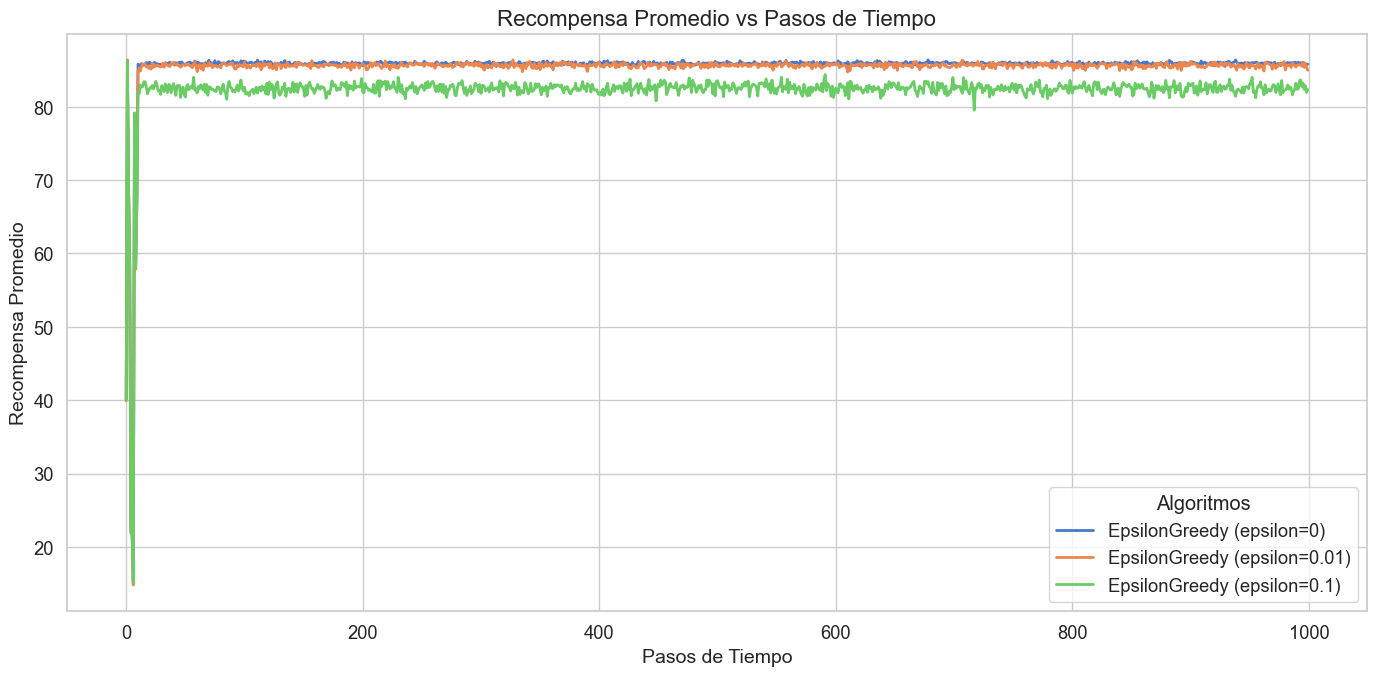

In [4]:

# Graficar los resultados
plot_average_rewards(steps, rewardsEpsilon, algorithmsEpsilon)


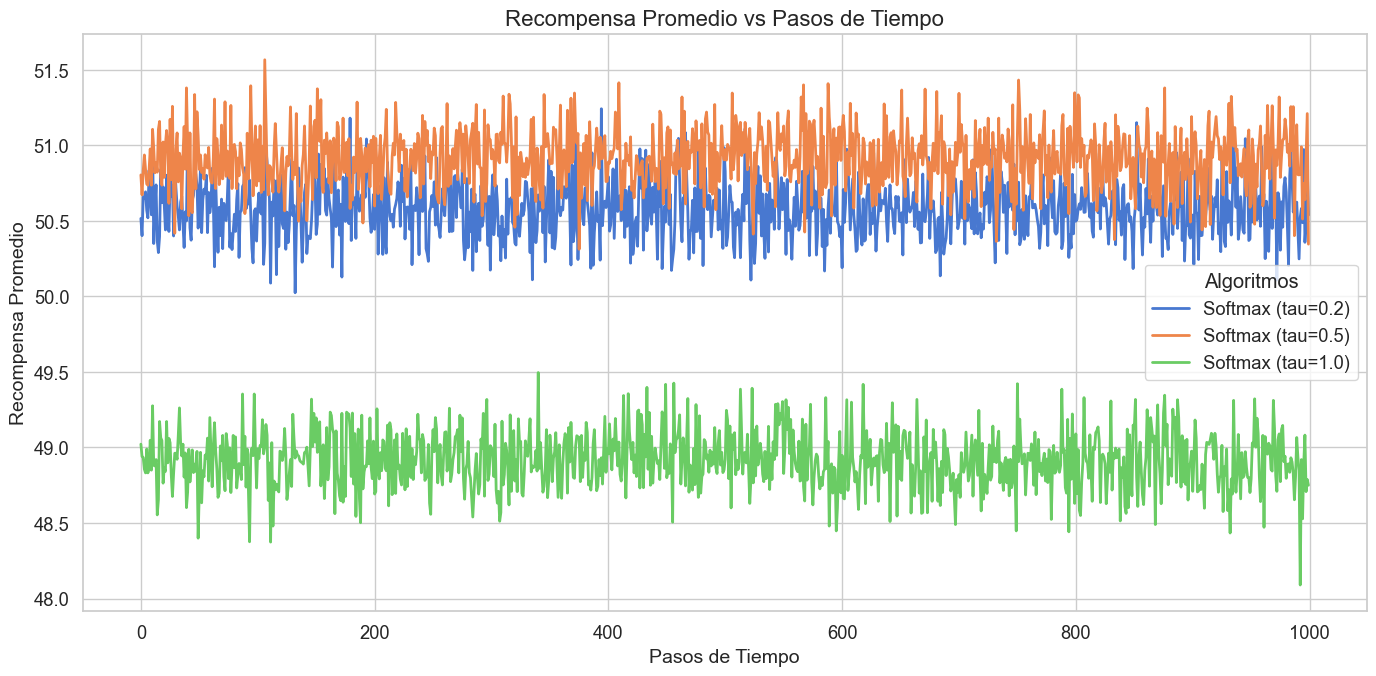

In [5]:

# Graficar los resultados
plot_average_rewards(steps, rewardsSoftmax, algorithmsSoftmax)

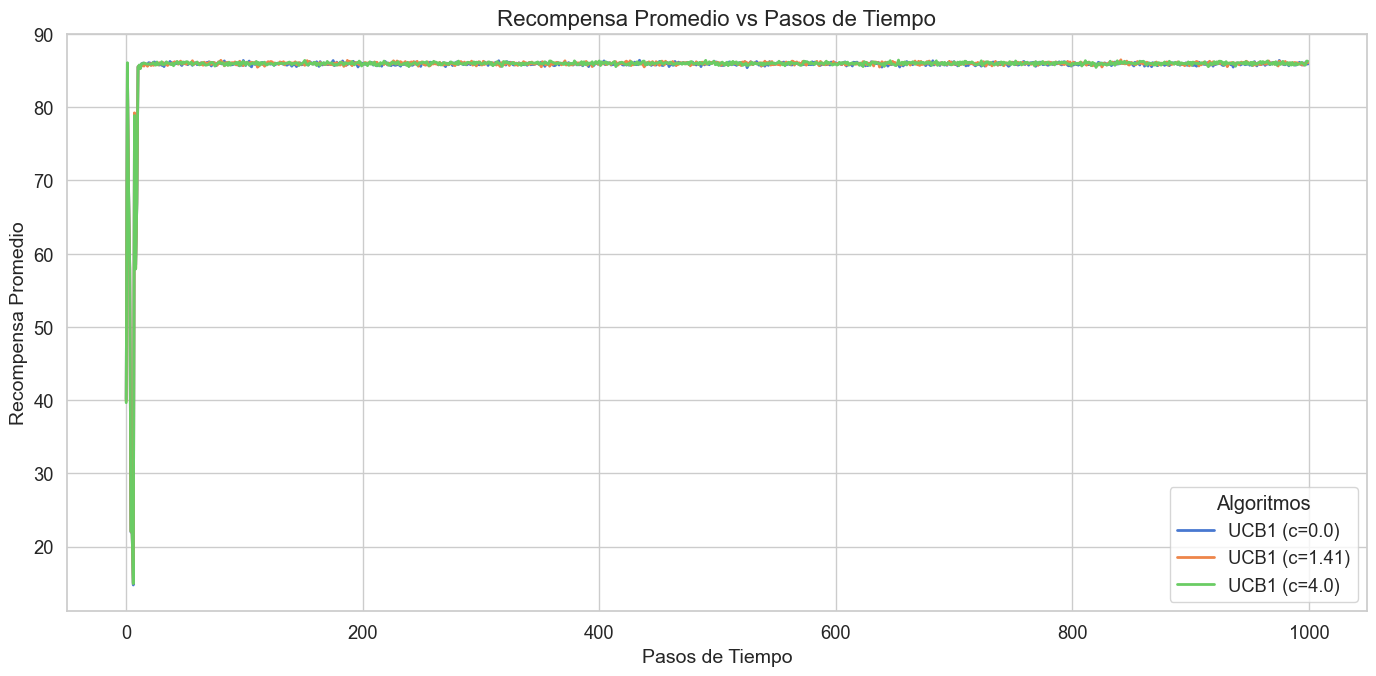

In [6]:

# Graficar los resultados
plot_average_rewards(steps, rewardsUCB1, algorithmsUCB1)

### Análisis detallado sobre la recompensa promedio vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido binomial. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo:

1. **Crecimiento de la recompensa promedio en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   En el entorno **Binomial**, podemos ver que tanto la línea **azul (ε=0)** como línea **naranja (ε=0.01)**, alcanzan los valores más altos. Esto sugiere que la separación entre las probabilidades de éxito podrían ser lo suficientemente grande como para que incluso una estrategia puramente **explotadora** logre identificar el óptimo con relativa facilidad.

   Por el contrario, en la línea **verde (ε=0.1)**, podemos ver una recompensa promedia inferior al resto, haciéndonos ver que una exploración del 10% no aporta suficiente ventaja frente a la **explotación** pura o una **exploración** mínima en este escenario concreto, posiblemente sea debido a que añadir un poco de **exploración** hace que el algoritmo introduzca pequeñas pérdidas acumuladas sin mejorar el proceso de identificación el óptimo.

2. **Crecimiento de la recompensa promedio en el algoritmo Softmax:**


   - La línea **naranja ($\tau$=0.5)** con una temperatura equilibrada la línea demuestra una recompensa promedio un poco mejor que el resto de líneas aunque permanece constante, indicando que la **exploración** ralentiza la **explotación** de mejores brazos, limitando la recompensa promedio a lo largo de los pasos de tiempo.
   - La línea **azul ($\tau$=0.2)** hace un comportamiento similar al de la línea naranja, manteniéndose constante. Esto se debe a que el algoritmo **explota** los brazos con mejores valores estimados iniciales que hace que la línea no mejore a falta de haber más exploración y probar con otros brazos con menor valor estimado.
   - La línea **verde ($\tau$=1.0)** pese a tener la configuración con más exploración de las 3 configuraciones, no hace crecer a la línea, debido a que el algoritmo va seleccionando brazos con menor valor estimado y no permite que el algoritmo se detenga lo suficiente en cada uno de ellos para experimentar una mejoría, ya que en este caso el crecimiento sería muy lento.

3. **Crecimiento de la recompensa promedio en el algoritmo UCB1:**

   Aquí podemos observar como las 3 líneas, **azul c=0.0**, **naranja c=1.41** y **verde(c=4.0)**, se solapan entre ellas durante prácticamente en todos los pasos de tiempo, esto se debe a que UCB1 es un algoritmo suficientemente robusto, que hace que aunque cambiemos los coeficientes para explorar estrategias de **explotación**, **exploración** o un equilibrio entre ambas, el algoritmo encuentra con facilidad el brazo óptimo. Esto sucede porque el algoritmo siempre inicia con una **exploración** inicial que hace que los brazos sean seleccionados varias veces, lo que permite obtener buenas estimaciones de sus recompensas esperadas. Una vez que el algoritmo identifica el brazo óptimo, tiende a seleccionarlo con mayor frecuencia, independientemente del valor del coeficiente c. Aunque valores más altos de $c$ introducen mayor **exploración**, el algoritmo sigue convergiendo hacia el brazo óptimo, mientras que valores bajos favorecen la **explotación**. En este entorno, ambas estrategias terminan produciendo resultados muy similares, lo que explica que las tres curvas evolucionen prácticamente de la misma manera.

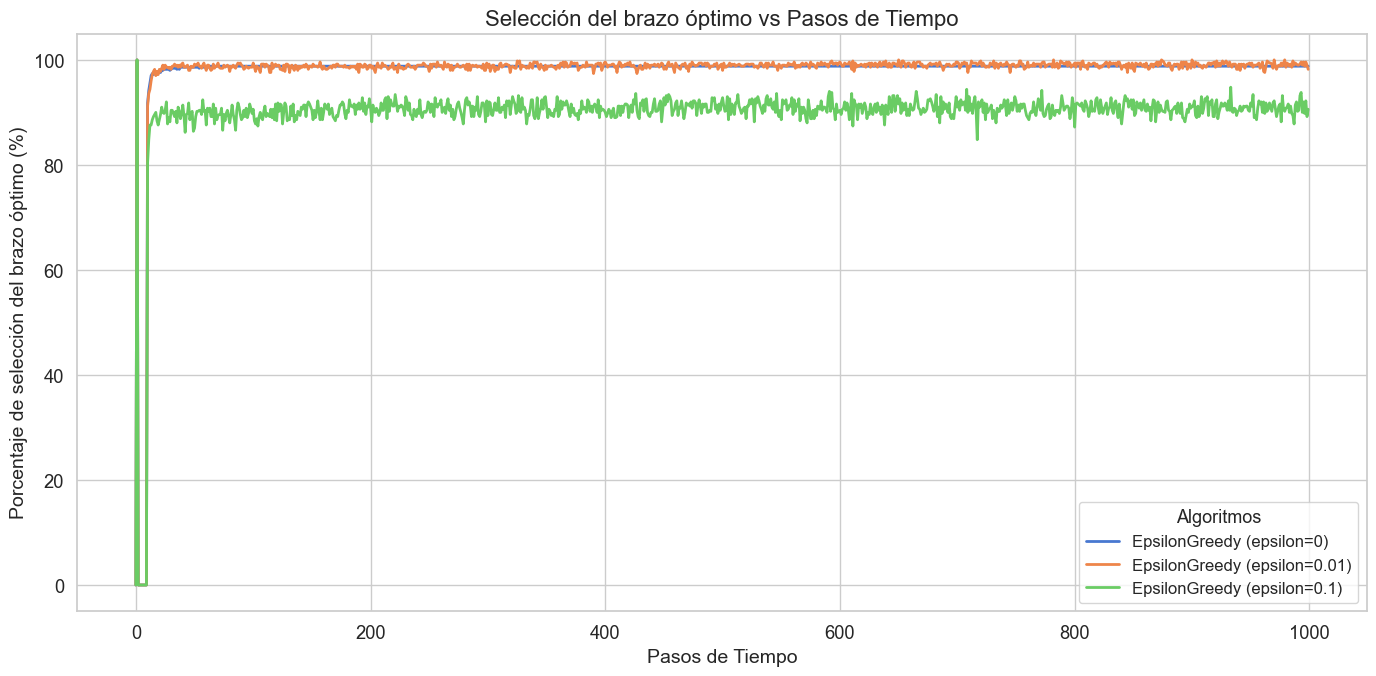

In [7]:
plot_optimal_selections(steps, optimal_selections_Epsilon, algorithmsEpsilon)

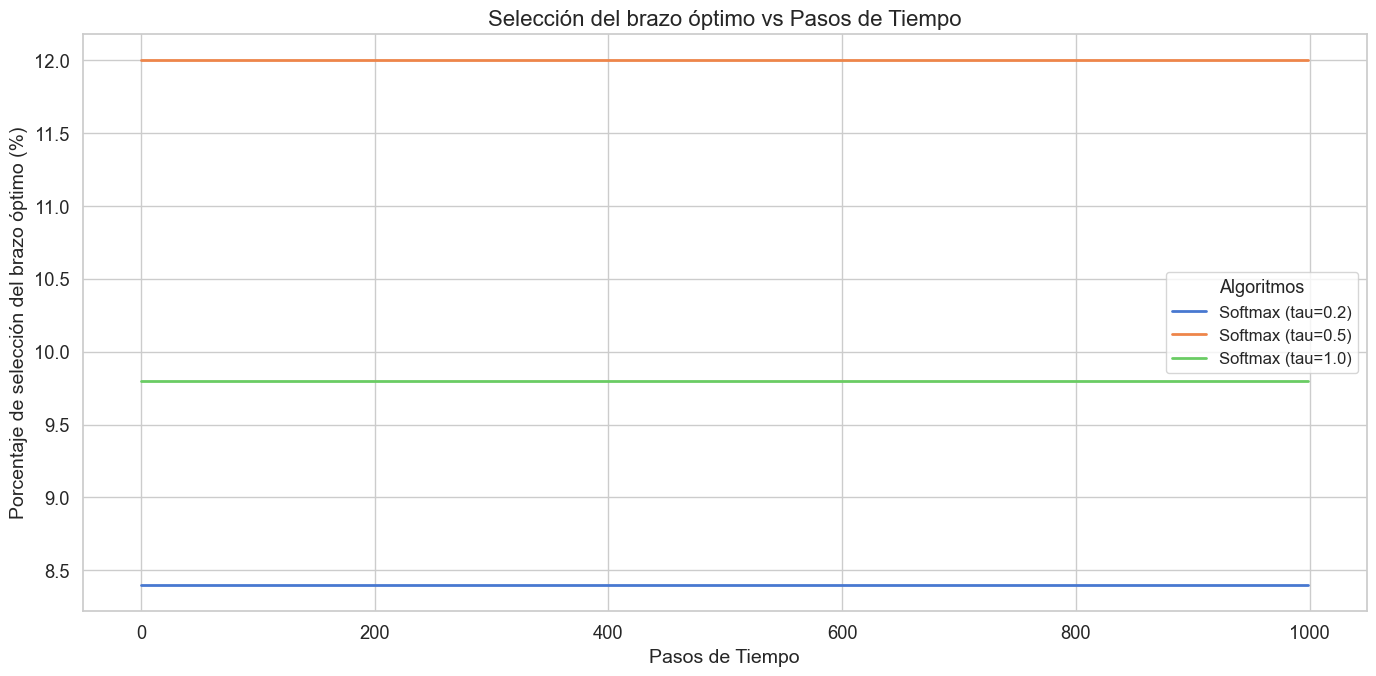

In [8]:
plot_optimal_selections(steps, optimal_selections_Softmax, algorithmsSoftmax)

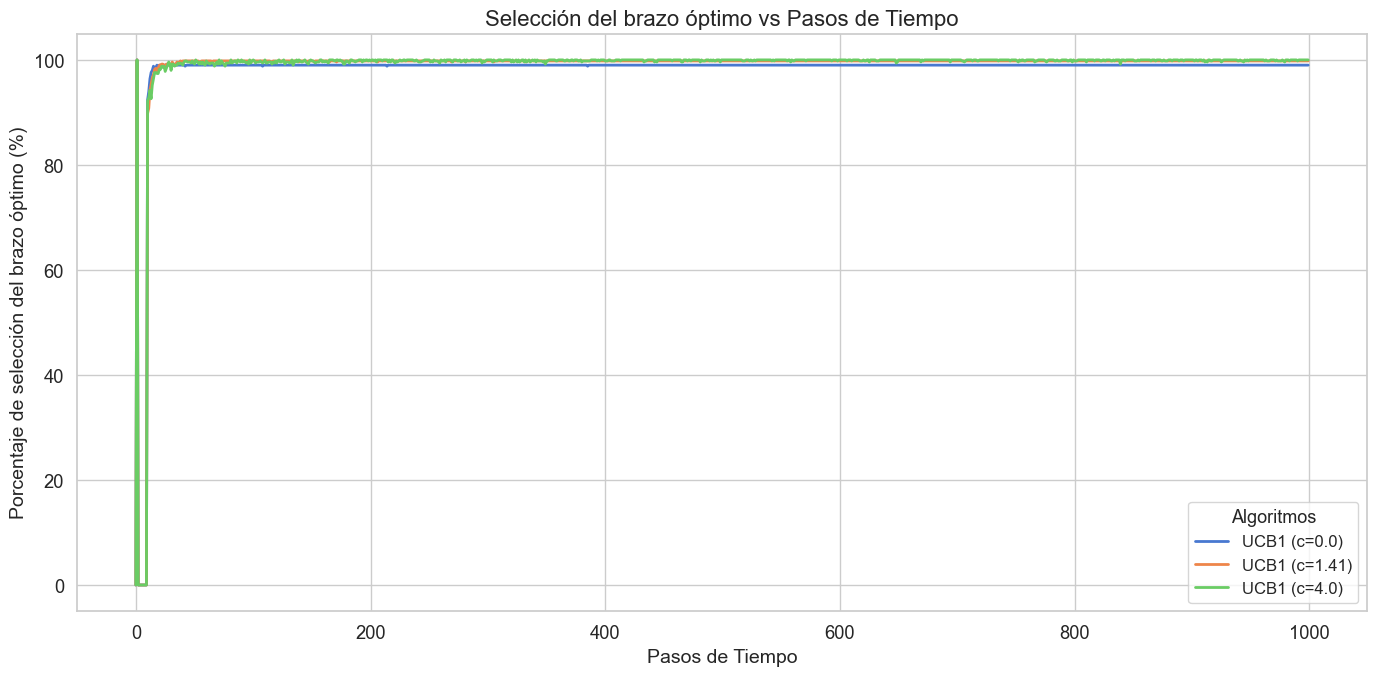

In [9]:
plot_optimal_selections(steps, optimal_selections_UCB1, algorithmsUCB1)

### Análisis detallado sobre la selección del brazo óptimo vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Selección del brazo óptimo vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido binomial. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de selección del brazo óptimo** obtenido por cada algoritmo:

1. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   Con respecto a la línea **azul (ε=0)** y la línea **naranja (ε=0.01)**, podemos ver que en ambas configuraciones las líneas convergen rápidamente hacia el 100% de selección del brazo óptimo, lo que indica que en nuestro entorno **binomial** la separación entre las probabilidades de los brazos es lo suficientemente grande como para que el algoritmo identifique el brazo óptimo en los primeros pasos de tiempo y permanezca allí, gracias a la estrategia **explotadora** de estas dos configuraciones del algoritmo.

   En cuanto a la línea **verde (ε=0.1)** podemos ver en la gráfica que tiene un crecimiento muy lento alrededor del 90% de selección de brazo óptimo, lo que nos indica que al haber un 10% de exploración, el algoritmo no explota lo suficiente el brazo óptimo y hace que el algoritmo busque otros brazos con menor valor estimado que el del brazo óptimo.

2. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo Softmax:**

   Podemos ver como las líneas **naranja ($\tau$=0.5)**, **verde ($\tau$=1.0)** y **azul ($\tau$=0.2)**, son completamente fijas a lo largo de los 1000 pasos de tiempo, esto se debe a que:

   - La línea **naranja ($\tau$=0.5)** al tener una temperatura equilibrada entre **explotación** y **exploración** se puede ver como la **exploración** ralentiza la **explotación** del algoritmo, haciendo que el algoritmo le cueste encontrar el brazo óptimo.

   - La línea **verde ($\tau$=1.0)** con temperatura alta, es una configuración de **exploración** que hace que el algoritmo pase bastante tiempo seleccionando brazos con menor valor estimado, pero que limita que se **exploten** lo suficiente antes de cambiar de brazo de nuevo, ralentizando el proceso de selección del brazo óptimo.

   - La línea **azul ($\tau$=0.2)** con temperatura baja, el algoritmo **explora** pocos brazos lo que hace que el algoritmo se estanque, esto hace difícil el proceso de selección del brazo óptimo.

3. **Crecimiento del porcentaje de selección del brazo óptimo en el algoritmo UCB1:**

   Aquí podemos observar como las 3 líneas, **azul c=0.0**, **naranja c=1.41** y **verde(c=4.0)**, se solapan entre ellas durante prácticamente en todos los pasos de tiempo, esto se debe a que UCB1 es un algoritmo suficientemente robusto, que hace que aunque cambiemos los coeficientes para explorar estrategias de **explotación**, **exploración** o un equilibrio entre ambas, el algoritmo encuentra con facilidad el brazo óptimo. Esto sucede porque el algoritmo siempre inicia con una **exploración** inicial que hace que los brazos sean seleccionados varias veces, lo que permite obtener buenas estimaciones de sus recompensas esperadas. Una vez que el algoritmo identifica el brazo óptimo, tiende a seleccionarlo con mayor frecuencia, independientemente del valor del coeficiente c. Aunque valores más altos de $c$ introducen mayor **exploración**, el algoritmo sigue convergiendo hacia el brazo óptimo, mientras que valores bajos favorecen la **explotación**. En este entorno, ambas estrategias terminan produciendo resultados muy similares, lo que explica que las tres curvas evolucionen prácticamente de la misma manera.

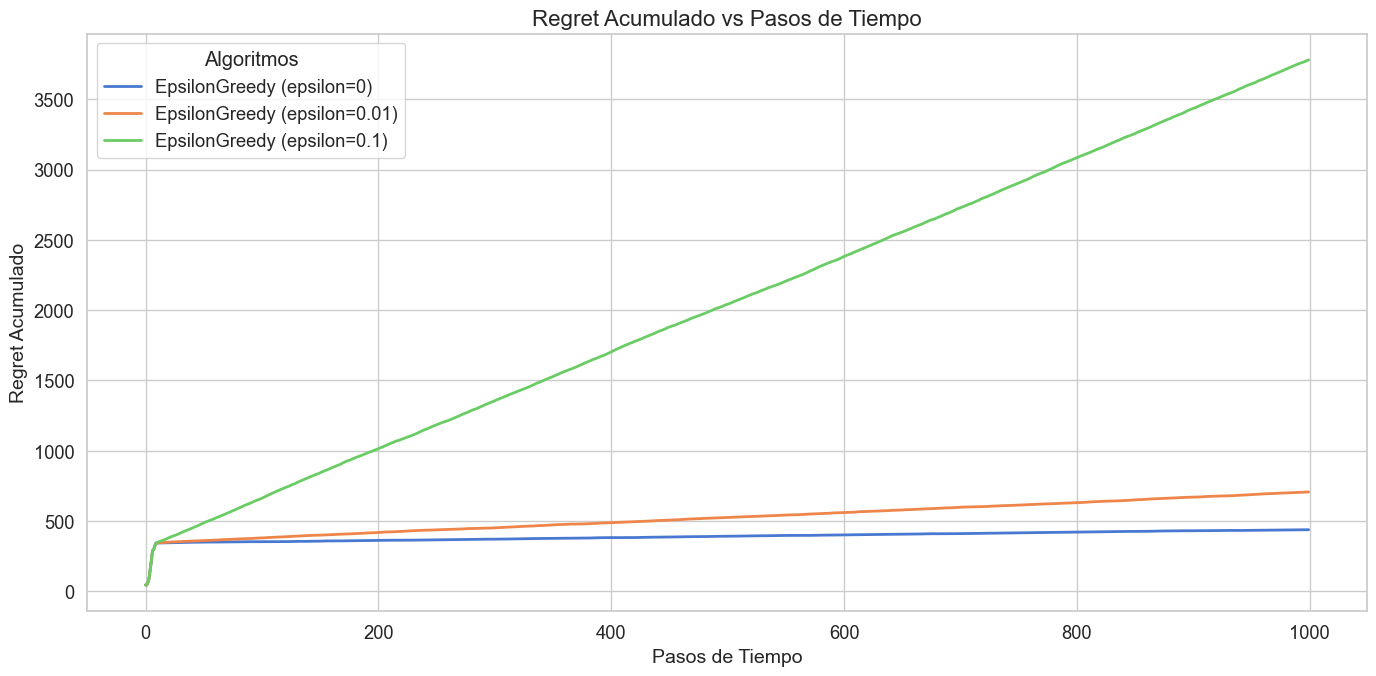

In [10]:
plot_regret(steps, regret_accumulated_Epsilon, algorithmsEpsilon)

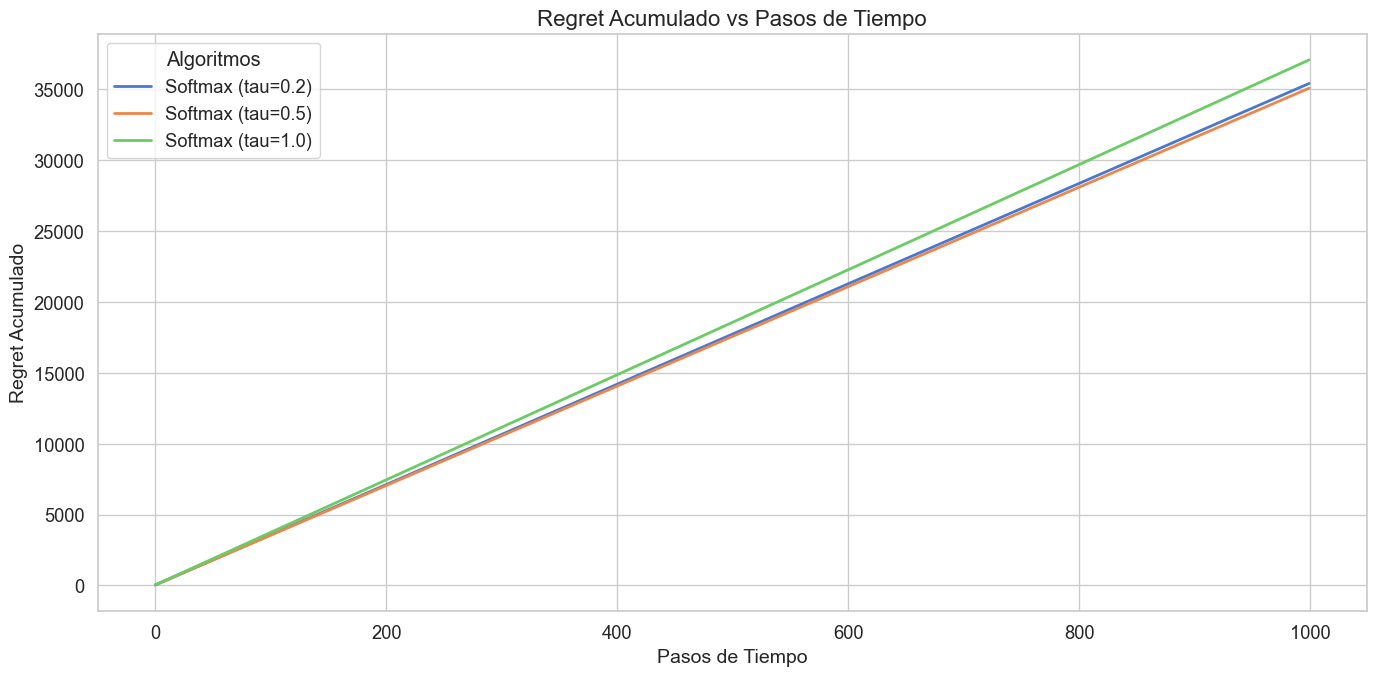

In [11]:
plot_regret(steps, regret_accumulated_Softmax, algorithmsSoftmax)

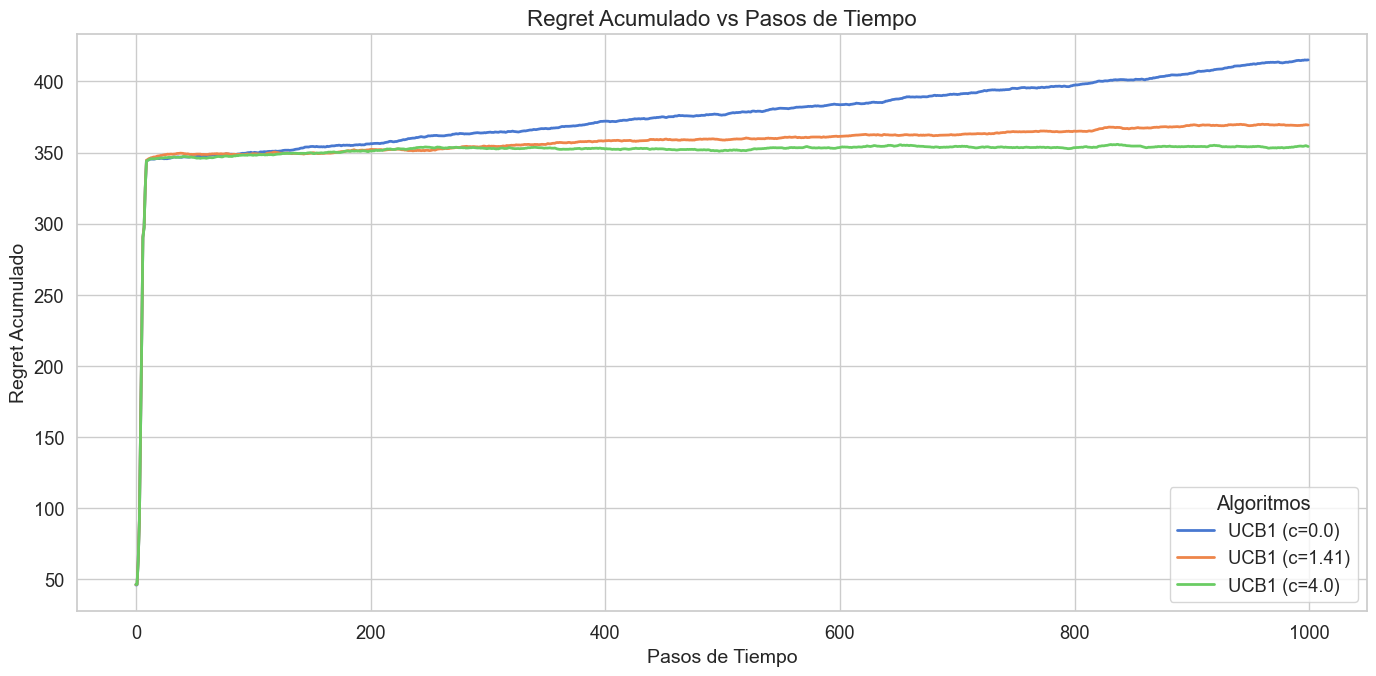

In [12]:
plot_regret(steps, regret_accumulated_UCB1, algorithmsUCB1)

### Análisis detallado sobre el regret acumulado vs pasos de tiempo

La imágenes muestran un gráfico de líneas titulado **"Regret acumulado vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido binomial. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **regret acumulado** obtenido por cada algoritmo:

1. **Crecimiento del regret acumulado en el algoritmo ε-Greedy:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores epsilon, ya que hacemos un análisis **exploratorio** al mismo comenzar que permite obtener estimaciones iniciales de todos los brazos, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   La línea **verde (ε=0.1)** demuestra un crecimiento más grande que las otras dos líneas debido a que era la línea que menos recompensa promedio tenía lo que hace que su lamento acumulado sea el más alto ya que su política de selección de brazos (10% de **exploración**), y que la forma de la línea sea una línea recta demuestra que la recompensa es constante aunque haya un aumento de selección óptima, que hace que se siga acumulando regret de manera estable a lo largo del tiempo.

   La línea **naranja (ε=0.01)** y la línea **azul (ε=0)** se puede ver como las líneas empiezan juntas, se separan poco después ya que la línea naranja una mayor crecimiento en su pendiente que la de la línea azul, demostrando que este 1% de **exploración** hace que el algoritmo seleccione brazos con menor valor estimado y esto conlleva a un mayor regret que la configuración **elitista**.

2. **Crecimiento del regret acumulado en el algoritmo Softmax:**

   Regret acumulado en el algoritmo Softmax demuestra la enorme pérdida en recompensas promedio del algoritmo, situación que ya hemos explicado en los anteriores análisis, además las líneas **azul ($\tau$=0.2)**, **naranja ($\tau$=0.5)** y **verde ($\tau$=1.0)** al principio se ven muy juntas, demostrando que la temperatura del algoritmo al inicio no influye demasiado, pero luego se separan ligeramente:

   - La línea **verde ($\tau$=1.0)** tiene una pendiente superior a la de las otras dos líneas, demostrando que una **temperatura alta**, hace que el algoritmo **explore** otros brazos menos óptimos y reduciendo su recompensa promedio y aumentando su regret.

   - La línea **azul ($\tau$=0.2)** con temperatura baja, demuestra tener un muy ligero aumento con respecto a la línea naranja, demostrando que esta estrategia que se centra más en la **explotación** hace que el algoritmo le cueste explorar y así encontrar brazos con mejores recompensas promedio.

   - La línea **naranja ($\tau$=0.5)** de temperatura media, aunque acumule menos regret que las otras dos configuraciones, demostrando que el equilibrio entre **exploración** y **explotación** sea mejor que las otras dos configuraciones, sigue siendo un regret que tiene mucho regret acumulado, demostrando una vez más que el algoritmo no muestre su eficacia en esta situación, donde los brazos son del tipo **binomial**.

3. **Crecimiento del regret acumulado en el algoritmo UCB1:**

   En los primeros pasos, se visualiza un comportamiento similar con respecto a los tres valores $c$, ya que obligatoriamente el algoritmo necesita seleccionar cada brazo al menos una vez para evitar una situación indefinida cuando el número de selecciones es cero, aunque esto cambia poco después, mostrando diferentes velocidades de convergencia en cada curva.

   La línea **azul c=0.0** experimenta un crecimiento incremental debido a que en su ganancia máxima permanece constante y en su selección de brazo óptimo también por lo que al ser una estrategia **explotadora**, no le da oportunidad a otros brazos con valor estimado inferior, lo que hace que casi nunca busque explorar otros brazos con la esperanza de seleccionar el brazo óptimo.

   En la línea **naranja c=1.41**, se puede ver que el crecimiento muy lento, lo que nos quiere decir que tanto en la recompensa promedio adquiere muy buenos valores, además de que en la selección de brazos converge al óptimo lo que hace que el regret experimente incrementos casi irrisorios debido tanto a su recompensa promedio como selección del brazo óptimo.

   La línea **verde(c=4.0)** también muestra un crecimiento muy lento, demostrando que la configuración de mayor **exploración** funciona mejor que las otras dos configuraciones más **elitistas** seguramente porque la exploración adicional permite confirmar antes cuál es el brazo óptimo.

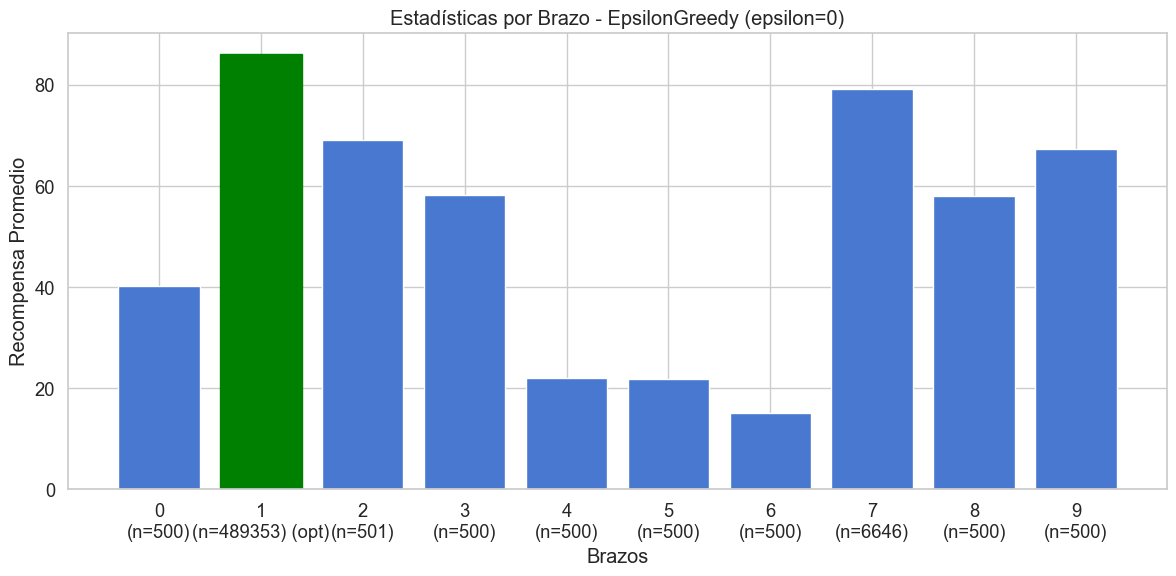

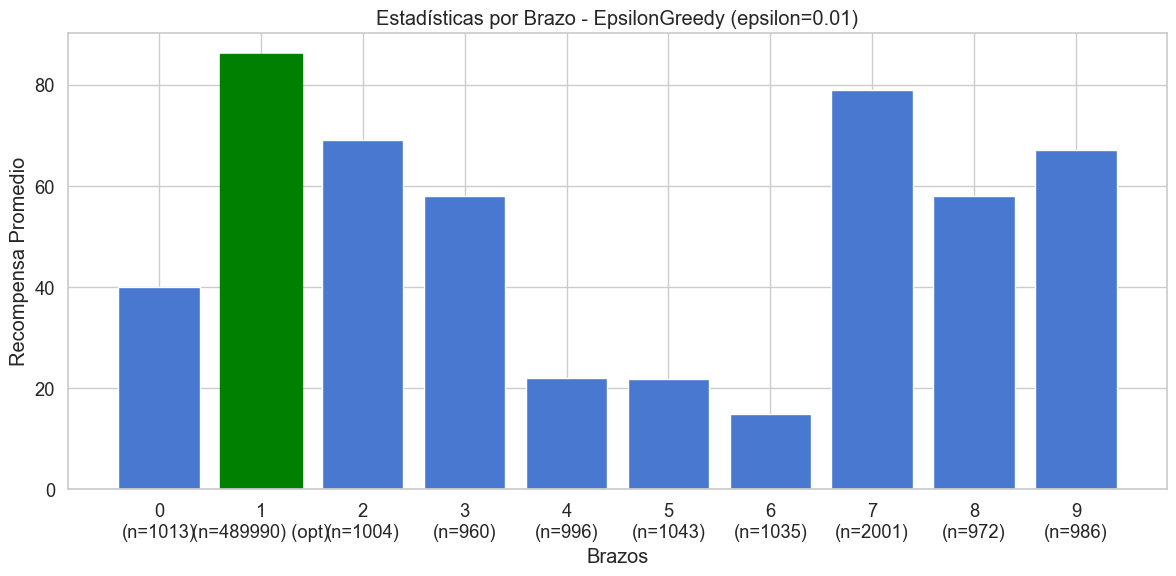

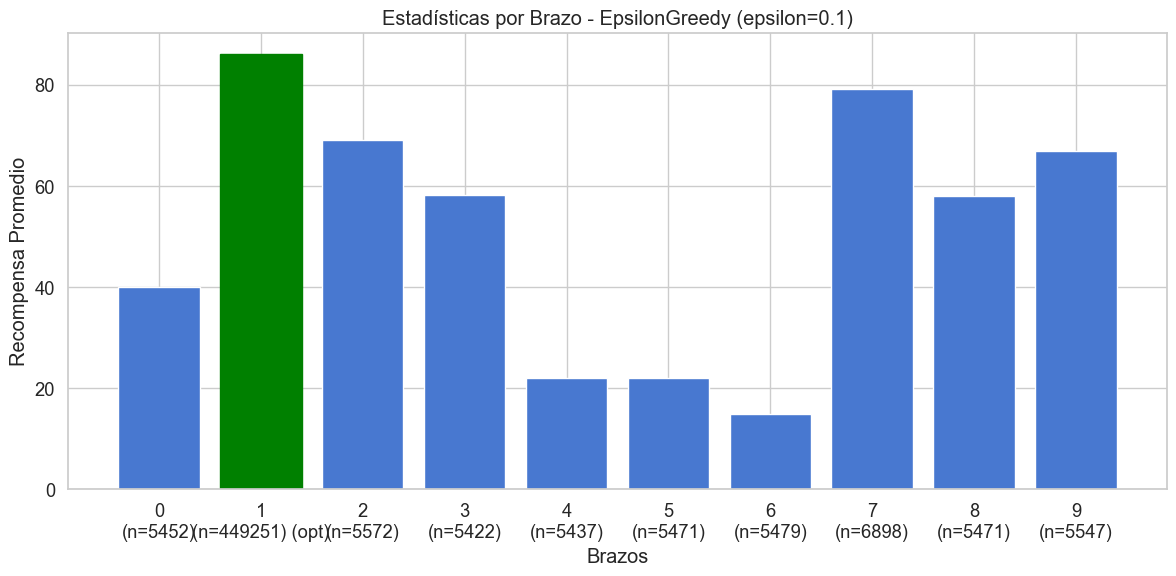

In [13]:
plot_arm_statistics(arm_stats_Epsilon, algorithmsEpsilon)

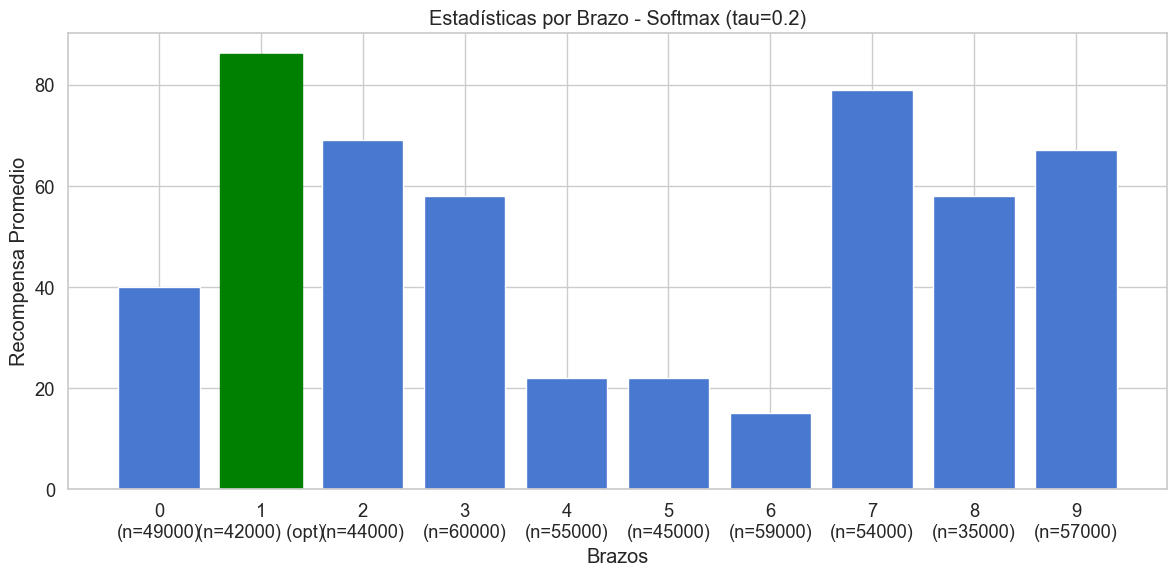

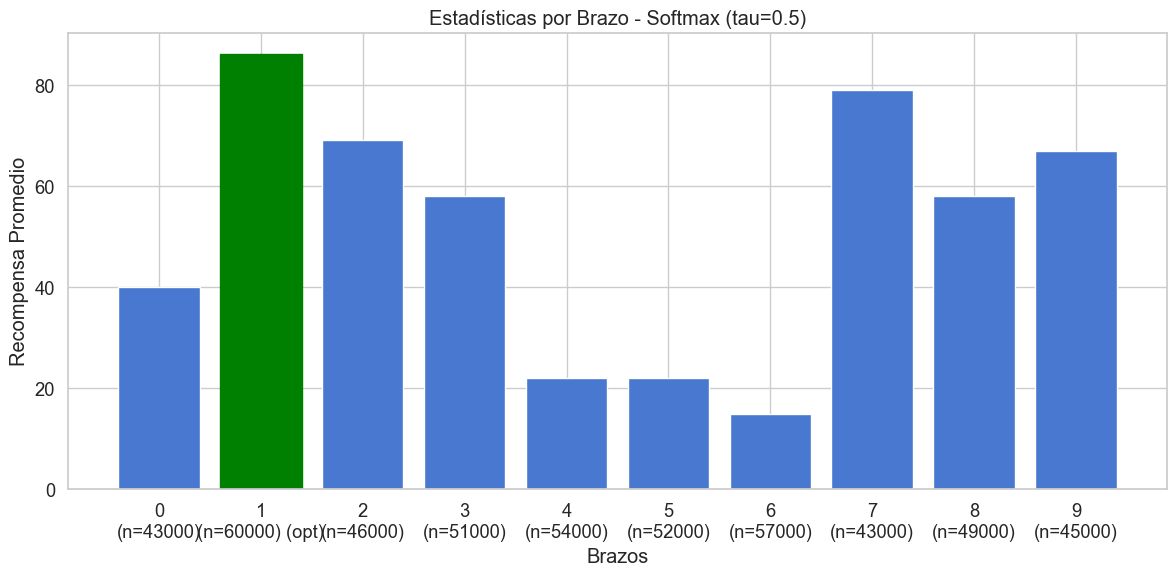

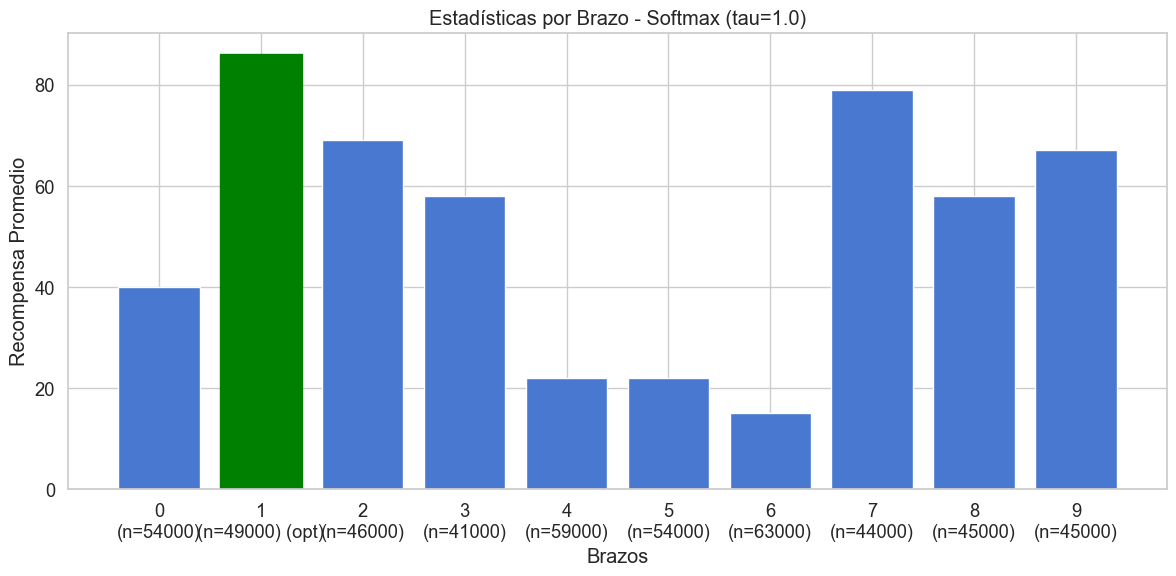

In [14]:
plot_arm_statistics(arm_stats_Softmax, algorithmsSoftmax)

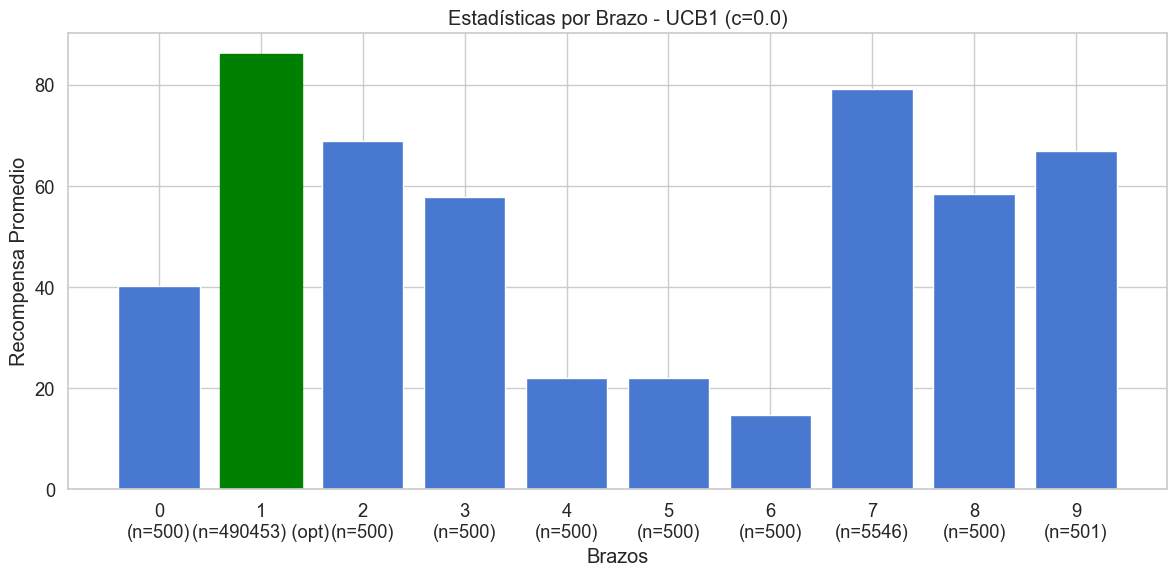

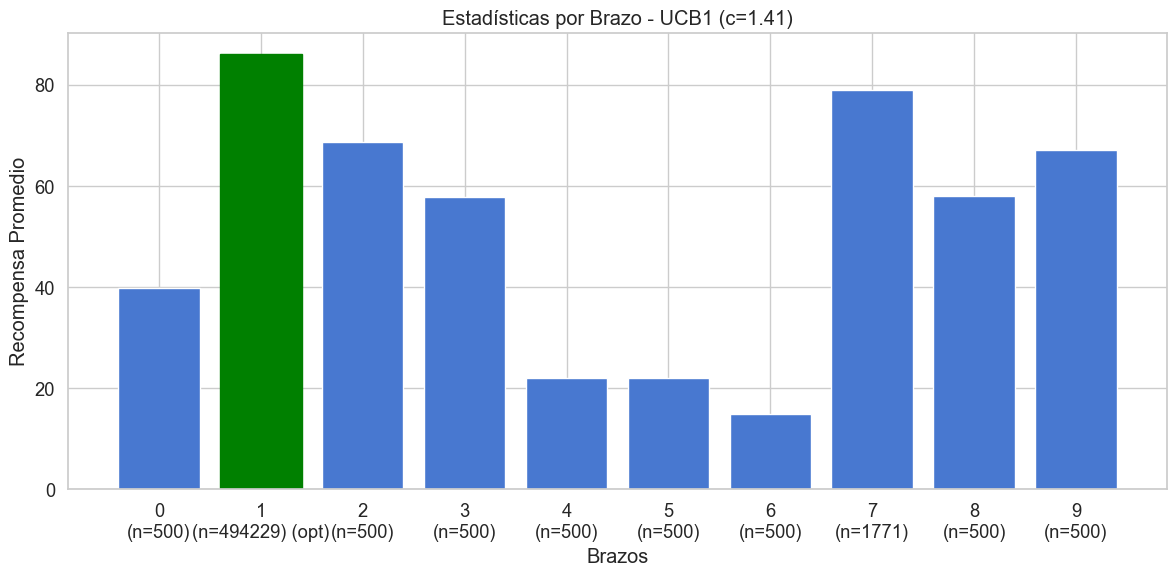

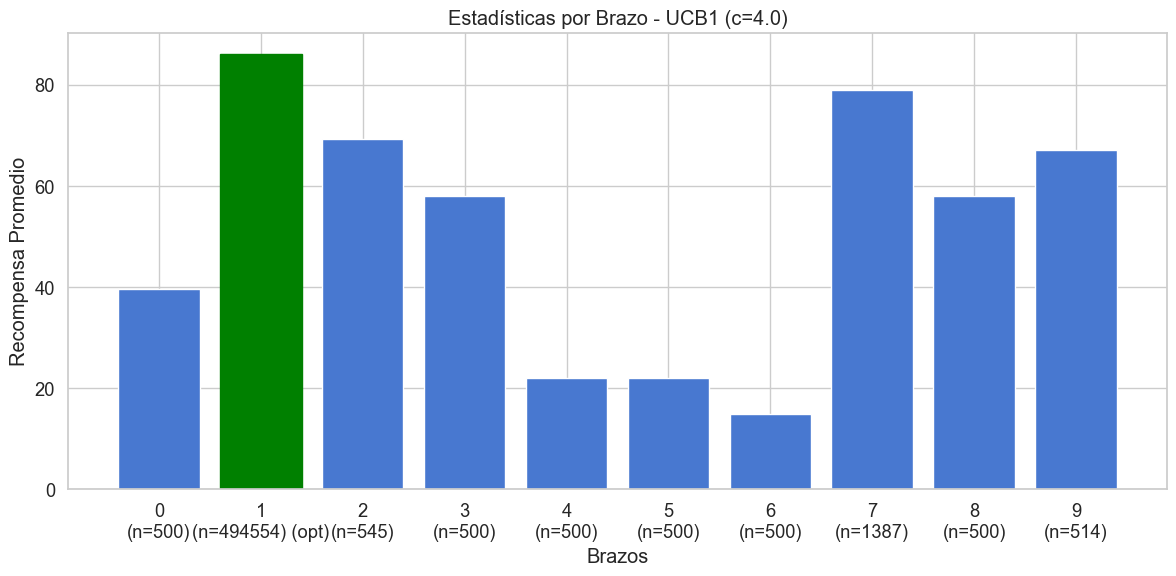

In [15]:
plot_arm_statistics(arm_stats_UCB1, algorithmsUCB1)

### Análisis detallado sobre las estadísticas por brazo

Las imágenes muestran un histograma titulado **"Estadísticas por Brazo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy**, **Softmax** y **UCB1** en un entorno de multi-armed bandit con el tipo de bandido binomial. En el eje **x** se representan los **brazos**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada brazo en cada algoritmo. Hay que tener en cuenta que cada algoritmo con cada configuración es ejecutado 500000 veces, en las cuales la recompensa promedio no variará entre gráficas ya que no es un valor influenciado por el tipo de algoritmo, además colorearemos con color verde el brazo con mayor recompensa promedio para que sea más fácil de visualizar. También tenemos que tener en cuenta que el brazo óptimo es el brazo 1 ya que contiene más probabilidad y en segundo lugar el brazo 7. Ahora hablaremos de las estadísticas de cada brazo por cada algoritmo dependiendo de su ε, $\tau$ y $c$:

1. **Estadísticas por brazo en el algoritmo ε-Greedy:**

   En **ε=0** podemos ver como el algoritmo ha seleccionado 489353 veces el brazo óptimo y 6646 el brazo subóptimo con más recompensa promedio, haciéndonos ver que en un 99.20% de las veces se elegirá entre el óptimo o el siguiente más óptimo, siendo un 97.87% las veces que elige el brazo más óptimo lo que representa que esta estrategia **explotadora** hace mucho uso del brazo óptimo y también bastante uso del subóptimo.

   En **ε=0.01** se selecciona el brazo óptimo 489990 veces y el siguiente más óptimo 2001 veces, siendo un 98.40% de las veces que se selecciona el brazo más óptimo o subóptimo y un 98% de veces que elige el brazo más óptimo lo que nos permite ver que con una **exploración** del 1% aunque se seleccionen más veces otros brazos con menor recompensa promedio, también selecciona más veces el brazo óptimo que con la estrategia puramente **explotadora** sugiriendo que seleccionar otros brazos con menor valor estimado, aumenta también las veces que se selecciona el brazo óptimo.

   En **ε=0.1** se puede ver como se selecciona el brazo óptimo 449251 veces y el siguiente brazo más óptimo, 6898 veces, siendo un 91.23% de las veces que elegirá el brazo más óptimo o más subóptimo dependiendo de la recompensa promedio y un 89.85% las veces que se selecciona el brazo más óptimo. Esto nos enseña que el algoritmo reduce la selección del brazo óptimo y subóptimo, ya que hace una exploración del 10% lo que conlleva a utilizar otros brazos con menos probabilidades.

2. **Estadísticas por brazo en el algoritmo Softmax:**

   En $\tau$=0.2 vemos como se selecciona 42000 el brazo óptimo y 54000 el brazo subóptimo con mayor recompensa promedio, siendo esto un 19.20% de selección para el brazo óptimo y subóptimo y un 8.4% la selección del brazo óptimo. Softmax con τ=0.2 es una estrategia bastante **explotadora**, por lo que depende fuertemente de las estimaciones iniciales. Si estas no reflejan correctamente la recompensa real de los brazos, el algoritmo puede quedar atrapado en brazos subóptimos durante gran parte de la ejecución.

   En $\tau$=0.5 el brazo óptimo se selecciona 60000 veces y el brazo más subóptimo en recompensa promedio un 43000 veces, siendo un  20.60% de las veces que se selecciona el brazo óptimo y subóptimo y un 12% de las veces que elige el brazo más óptimo. Con esto podemos ver como el algoritmo mejora en este caso al tener una estrategia más **exploradora** permitiendo que el algoritmo seleccione más veces el brazo óptimo y subóptimo.

   En $\tau$=1.0 se puede ver como el brazo óptimo se selecciona 49000 veces y el brazo más subóptimo 44000 siendo esto un 18.6% de veces que se selecciona el brazo óptimo y subóptimo y un 9.8% las veces que se selecciona el brazo óptimo. Esto demuestra que al tener una temperatura alta, y por lo tanto mayor **exploración** el algoritmo selecciona muchas más veces otros brazos con menos probabilidades en vez de enfocarse en el brazo óptimo.

3. **Estadísticas por brazo en el algoritmo UCB1:**

   En c=0.0 vemos como el brazo óptimo se selecciona 490453 veces y el brazo subóptimo 5546 veces, siendo esto un 99.20% de las veces que se selecciona el brazo óptimo y subóptimo y un 98.10% de las veces que se selecciona el brazo óptimo. Esto nos permite ver que el algoritmo con carácter mayormente **explotador** selecciona gran parte de las veces el algoritmo óptimo y subóptimo debido a que estos brazos tendrán una gran valor estimado que permite al algoritmo utilizarlos muchas veces.

   En c=1.41 se selecciona el brazo óptimo 494229 y el brazo subóptimo 1771 veces, siendo esto un 99.20% de las veces que se selecciona el brazo óptimo y subóptimo, y un 98.85% las veces que selecciona el brazo óptimo. Esto demuestra que la configuración de **explotación** y **exploración** intermedia, aunque en su conjunto seleccione el mismo porcentaje el conjunto brazo óptimo y subóptimo, pero también se puede ver que selecciona muchas más veces el brazo óptimo, lo que podría ser una estrategia más interesante que la **elitista**

   En c=4.0 podemos ver como se selecciona 494554 veces el brazo óptimo y 1387 veces el brazo subóptimo, siendo esto un 99.19% de las veces que el algoritmo selecciona el brazo óptimo y subóptimo y un 98.91% de las veces que selecciona el brazo óptimo. Aquí podemos observar que pese a tener una mayor **exploración** con esta configuración el algoritmo UCB1 selecciona un poco menos el conjunto de brazo óptimo y subóptimo pero selecciona más el brazo óptimo.

Esto demuestra que el algoritmo UCB1 demuestra en todas sus configuraciones una consistencia muy alta de selección de brazo óptimo y subóptimo a diferencia de los otros dos algoritmos.

## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)** con el tipo de bandidos **Binomial**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado en el estudio del algoritmo epsilon-greedy, softmax y UCB1, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráficas generadas:

### **1. Epsilon-greedy**
Hemos visto que el algoritmo epsilon-greedy en esta situación prefiere tener un comportamiento **explotador** más que **explorador** ya que a partir de las primeras estimaciones de recompensa el algoritmo puede identificar con relativa facilidad los brazos con mayor probabilidad de éxito, encontrando así también el brazo óptimo y el mas subóptimo, por lo que si el algoritmo tiene una configuración completamente elitista o se le una **exploración** del 1% el algoritmo no se desviará a otros brazos con menor recompensa promedio.

### **2. Softmax**
En este caso, aunque el algoritmo demuestra tener un mejor funcionamiento con una temperatura equilibrada, haciendo que haya un equilibrio entre **explotación** y **exploración**, sigue demostrando unas ganancias promedio mediocres, un porcentaje de selección del brazo óptimo muy malo, un enorme regret acumulado y un bajo porcentaje de selección de brazos óptimo.

### **3. UCB1**
En cuanto al algoritmo UCB1, muestra en las 3 configuraciones una gran recompensa promedio, uso del brazo óptimo y muy bajo regret, siendo ligeramente superior la configuración con $c=4.0$, que presenta el menor regret acumulado.

### **Comparación entre algoritmos**

Si comparamos los tres algoritmos, podemos observar que UCB1 es el que mejor funciona en este experimento, ya que todas sus configuraciones muestran una gran eficacia. Además, presenta la mayor recompensa promedio, el menor regret acumulado y el mayor porcentaje de selección del brazo óptimo.